# Project Title: 

# The Relationship Between Unemployment and U.S. Real GDP Growth 

## Project structure: 

- Define the research question.
- Download unemployment and GDP data.
- Inspect missing values and data types.
- Convert monthly unemployment into quarterly averages.
- Merge it with quarterly GDP.4
- Calculate GDP growth.
- Create the 5% unemployment indicator.
- Perform EDA.
- Conduct a Welch independent-samples t-test.
- Build a simple linear regression model.
- Evaluate the model.
- Explain limitations and conclusions.

# Step 1. Data Collection  

### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

### Download the datasets 

In [2]:
# unemployment

unemployment_url= "https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE"
df_unem = pd.read_csv(unemployment_url)
df_unem.head()

,observation_date,UNRATE
0,1948-01-01,3.4
1,1948-02-01,3.8
2,1948-03-01,4.0
3,1948-04-01,3.9
4,1948-05-01,3.5


In [3]:
## GDP 

gdp_url= "https://fred.stlouisfed.org/graph/fredgraph.csv?id=GDPC1"
df_gdp= pd.read_csv(gdp_url)
df_gdp.head()

,observation_date,GDPC1
0,1947-01-01,2182.681
1,1947-04-01,2176.892
2,1947-07-01,2172.432
3,1947-10-01,2206.452
4,1948-01-01,2239.682


#### The two datasets : 
 - GDP is quarterly
 - Unemployment is monthly

### Clean Data

In [4]:
df_unem.isnull().sum()

observation_date    0
UNRATE              1
dtype: int64

In [5]:
df_unem["UNRATE"]= df_unem.UNRATE.fillna(df_unem.UNRATE.mean())

In [6]:
# Check the null values

df_unem.isnull().sum()

observation_date    0
UNRATE              0
dtype: int64

In [7]:
df_gdp.isnull().sum()

observation_date    0
GDPC1               0
dtype: int64

### Covert observation_date to datetime 

In [8]:
df_unem["observation_date"]= pd.to_datetime(df_unem["observation_date"])
df_gdp["observation_date"]=pd.to_datetime(df_gdp["observation_date"])

### Convert values to numeric  

In [9]:
df_unem["UNRATE"] = pd.to_numeric(df_unem["UNRATE"], errors= "coerce")
df_gdp["GDPC1"]=pd.to_numeric(df_gdp["GDPC1"], errors= "coerce")

### Checking the missing data

In [10]:
print("Missing unemployment values:")
print(df_unem.isna().sum())

print("\nMissing GDP values:")
print(df_gdp.isna().sum())

Missing unemployment values:
observation_date    0
UNRATE              0
dtype: int64

Missing GDP values:
observation_date    0
GDPC1               0
dtype: int64


# Step 2. Select a study period 

In [11]:
start_date= "1960-01-01"

df_unem= df_unem[df_unem["observation_date"]>= start_date].copy()
df_gdp = df_gdp[df_gdp["observation_date"]>= start_date].copy()

# Step 3. Convert monthly unemployment to quarterly data 

In [12]:
df_unem= df_unem.set_index ("observation_date")

df_unem_quarterly= (df_unem["UNRATE"].resample("QS").mean().reset_index())
# QS means "quarter-start frequency". 
# Each quarterly value represents the average unemployment rate across the three months in that quarter.

df_unem_quarterly.head()

,observation_date,UNRATE
0,1960-01-01,5.133333
1,1960-04-01,5.233333
2,1960-07-01,5.533333
3,1960-10-01,6.266667
4,1961-01-01,6.800000


# Step 4. Calculate GDP growth

In [13]:
df_gdp = df_gdp.sort_values ("observation_date")
df_gdp["GDP_Growth"]= df_gdp["GDPC1"].pct_change() *100
# pct_change()= the function computes percentage change from the previous row

df_gdp.head()

,observation_date,GDPC1,GDP_Growth
52,1960-01-01,3517.181,NaN
53,1960-04-01,3498.246,-0.538357
54,1960-07-01,3515.385,0.489931
55,1960-10-01,3470.278,-1.283131
56,1961-01-01,3493.703,0.675018


The first observation will have a missing GDP growth value because there is no earlier quarter with which to compare it.

# Step 5. Merge the datasets

In [14]:
df= pd.merge (df_gdp,df_unem_quarterly, on= "observation_date", how= "inner")

df=df.dropna().reset_index(drop=True)
df.head()

,observation_date,GDPC1,GDP_Growth,UNRATE
0,1960-04-01,3498.246,-0.538357,5.233333
1,1960-07-01,3515.385,0.489931,5.533333
2,1960-10-01,3470.278,-1.283131,6.266667
3,1961-01-01,3493.703,0.675018,6.800000
4,1961-04-01,3553.021,1.697855,7.000000


In [15]:
df.describe()

,observation_date,GDPC1,GDP_Growth,UNRATE
count,264,264.000000,264.000000,264.000000
mean,1993-02-14 12:10:54.545454,11883.396110,0.738457,5.861689
min,1960-04-01 00:00:00,3470.278000,-7.876784,3.400000
25%,1976-09-08 00:00:00,6439.606500,0.346776,4.633333
50%,1993-02-15 00:00:00,10607.061000,0.758476,5.566667
75%,2009-07-24 00:00:00,16845.826000,1.128664,6.908333
max,2026-01-01 00:00:00,24180.419000,7.762279,13.000000
std,NaN,5952.695668,1.052468,1.690784


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  264 non-null    datetime64[us]
 1   GDPC1             264 non-null    float64       
 2   GDP_Growth        264 non-null    float64       
 3   UNRATE            264 non-null    float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 8.4 KB


In [17]:
df.corr()

,observation_date,GDPC1,GDP_Growth,UNRATE
observation_date,1.000000,0.988725,-0.136171,-0.069846
GDPC1,0.988725,1.000000,-0.119337,-0.155775
GDP_Growth,-0.136171,-0.119337,1.000000,-0.121698
UNRATE,-0.069846,-0.155775,-0.121698,1.000000


In [18]:
print(df["observation_date"].max())
print(df["observation_date"].min())

2026-01-01 00:00:00
1960-04-01 00:00:00


# Step 6. Create the 5% indicator

In [19]:
df["High_unemployment"]= np.where(df["UNRATE"] >= 5, "At least 5%", "Below 5%")
df["Unemployment_Group"]=np.where(df["UNRATE"]>= 5, "At least 5%", "Below 5%")
df.head()

,observation_date,GDPC1,GDP_Growth,UNRATE,High_unemployment,Unemployment_Group
0,1960-04-01,3498.246,-0.538357,5.233333,At least 5%,At least 5%
1,1960-07-01,3515.385,0.489931,5.533333,At least 5%,At least 5%
2,1960-10-01,3470.278,-1.283131,6.266667,At least 5%,At least 5%
3,1961-01-01,3493.703,0.675018,6.800000,At least 5%,At least 5%
4,1961-04-01,3553.021,1.697855,7.000000,At least 5%,At least 5%


The indicator means:\
High unemployment = \
<br>1, UNRATE ≥ 5%\
<br>0, UNRATE < 5%

# Step 7. EDA

### Summary statistics by group 


In [20]:
group_summary= (
    df.groupby("Unemployment_Group")["GDP_Growth"].agg(["count","mean","median","std","min","max"])
)

group_summary

,count,mean,median,std,min,max
Unemployment_Group,,,,,,
At least 5%,175,0.728393,0.774952,1.201429,-7.876784,7.762279
Below 5%,89,0.758246,0.721900,0.675150,-1.316322,2.474942


### Distribution of GDP growth

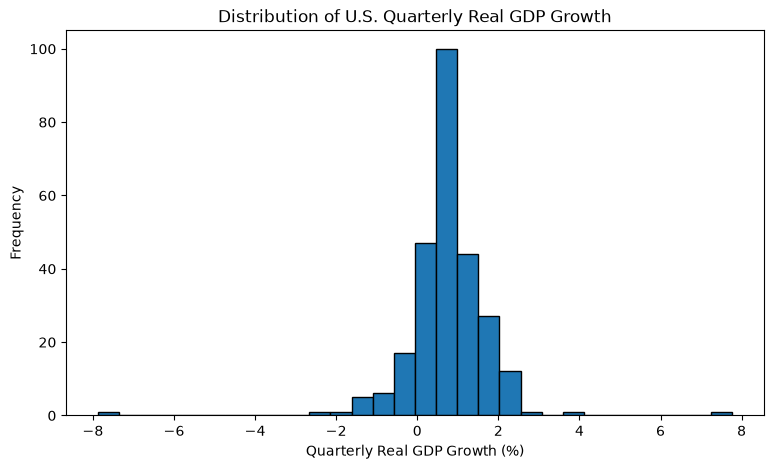

In [21]:
plt.figure(figsize= (9,5))

plt.hist(df["GDP_Growth"], bins = 30, edgecolor='black')

plt.xlabel("Quarterly Real GDP Growth (%)")
plt.ylabel("Frequency")
plt.title("Distribution of U.S. Quarterly Real GDP Growth")
plt.show()

### Boxplot by unemployment group

<Figure size 800x500 with 0 Axes>

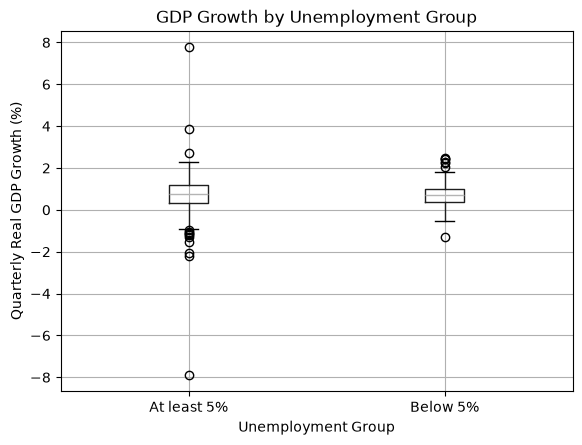

In [22]:
plt.figure(figsize=(8,5))

df.boxplot(column= "GDP_Growth", 
          by= "Unemployment_Group")

plt.xlabel("Unemployment Group")
plt.ylabel("Quarterly Real GDP Growth (%)")
plt.title("GDP Growth by Unemployment Group")
plt.suptitle("")
plt.show()

### Scatter Plot

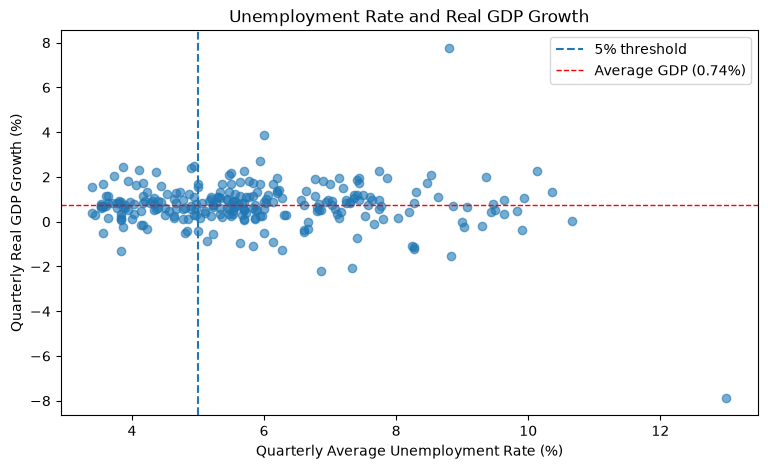

Average GDP is  0.7384572386597842


In [23]:
plt.figure (figsize=(9,5))

plt.scatter(df["UNRATE"],df["GDP_Growth"],alpha=0.6)

plt.axvline(x=5, linestyle= '--', label= "5% threshold")

avg_growth= df["GDP_Growth"].mean()
plt.axhline(
    y=avg_growth, 
    color= 'r', 
    linestyle= '--', 
    linewidth= 1, 
    label=f"Average GDP ({avg_growth:.2f}%)"
)

plt.xlabel ("Quarterly Average Unemployment Rate (%)")
plt.ylabel ("Quarterly Real GDP Growth (%)")
plt.title ("Unemployment Rate and Real GDP Growth")
plt.legend()
plt.show()

print("Average GDP is ", avg_growth)

### Time-series plot

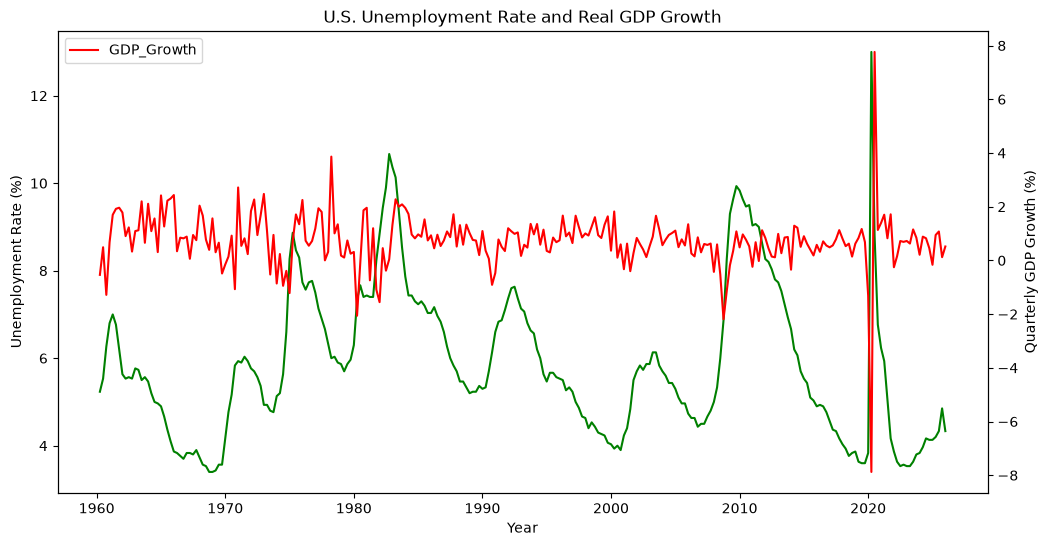

In [24]:
fig, ax1 = plt.subplots(figsize= (12,6))

ax1.plot(
    df["observation_date"], 
    df["UNRATE"], 
    label= "Unemployment Rate", 
    color='g'
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Unemployment Rate (%)")

ax2=ax1.twinx()

ax2.plot(df["observation_date"], 
         df["GDP_Growth"], 
         label= "GDP_Growth",
         color= 'red')
ax2.set_ylabel("Quarterly GDP Growth (%)")

plt.title("U.S. Unemployment Rate and Real GDP Growth")
plt.legend()
plt.show()

# Step 8. Hypothesis Testing 

### Seperate two groups 

In [25]:
high_unemployment = df.loc[df["UNRATE"]>= 5, "GDP_Growth"]
low_unemployment  = df.loc[df["UNRATE"]< 5 , "GDP_Growth"]

print("High-unemployment observations:", len(high_unemployment))
print("Low-unemployment observations:", len(low_unemployment))
print("High-unemployment mean GDP growth:",high_unemployment.mean())
print("Low-unemployment mean GDP growth:",low_unemployment.mean())

High-unemployment observations: 175
Low-unemployment observations: 89
High-unemployment mean GDP growth: 0.7283930621216645
Low-unemployment mean GDP growth: 0.7582463498302441


### Welch's t-test

In [26]:
t_stats, two_sided_p_value = stats.ttest_ind(
    high_unemployment, 
    low_unemployment,
    equal_var=False,
    nan_policy = 'omit'
)

print("T-statistic:", t_stats)
print("Two-sided p-value:", two_sided_p_value)

T-statistic: -0.2581838793341449
Two-sided p-value: 0.7964697154090858


### Interpretation:
1. The average GDP growth during periods of high unemployment is lower than during periods of low unemployment based on the t-statisitc is negative value.  
2. small absolute t-statistic (|t| = 0.258) indicates that the observed difference in mean GDP growth between the two groups is very small relative to the sampling variability.
3. This t-test did not find statistically significant evidence of a difference in the means.
4. There is insufficient evidence that the two population means differ througn the observation of p-value (p=0.796>0.05)

### Professional Interpretation: 

The t-test produced a t-statistic of −0.258 and a two-sided p-value of 0.796. The negative t-statistic suggests that the sample mean GDP growth during periods of high unemployment is slightly lower than during periods of low unemployment. However, the magnitude of the t-statistic is very small, indicating that the observed difference in sample means is small relative to the sampling variability. Since the p-value (0.796) is much greater than the significance level of 0.05, we fail to reject the null hypothesis. Therefore, there is insufficient statistical evidence to conclude that average GDP growth differs between periods of high and low unemployment.

### Decision rule

In [27]:
alpha = 0.05 

if two_sided_p_value < alpha:
    print("Reject H0.")
    print(
        "GDP growth is significantly different "
        "between the two unemployment groups."
    )
else:
    print("Fail to reject H0.")
    print(
        "The data do not provide enough evidence "
        "of a significant difference."
    )

Fail to reject H0.
The data do not provide enough evidence of a significant difference.


### <Optional: One-sided test>

#### Ha: 𝒰 (high) < 𝒰 (low)  

In [28]:
one_sided_result = stats.ttest_ind(
    high_unemployment,
    low_unemployment,
    equal_var=False,
    alternative="less"
)

print(one_sided_result)

TtestResult(statistic=np.float64(-0.2581838793341449), pvalue=np.float64(0.3982348577045429), df=np.float64(259.4093872488751))


# Step 9. Add effect size

#### A p-value tells you whether the difference is statistically significant.

#### It does not tell you **how large the difference is**. (If there is a statistically significant.)

In [29]:
# Calculate Cohen’s d:

def cohens_d(group1, group2):
    n1 = len(group1)
    n2 = len(group2)

    variance1 = group1.var(ddof=1)
    variance2 = group2.var(ddof=1)

    pooled_variance = (
        ((n1 - 1) * variance1) +
        ((n2 - 1) * variance2)
    ) / (n1 + n2 - 2)

    pooled_std = np.sqrt(pooled_variance)

    return (
        group1.mean() - group2.mean()
    ) / pooled_std


effect_size = cohens_d(
    high_unemployment,
    low_unemployment
)

print("Cohen's d:", effect_size)

Cohen's d: -0.0283135998811932


the negative sign does not matter, we can use **∣d∣** to observe the result. 

| Cohen's d | Interpretation    |
| --------: | ----------------- |
|       0.2 | Small effect      |
|       0.5 | Medium effect     |
|       0.8 | Large effect      |
|      >1.2 | Very large effect |


#### Summary: 
| Statistic       | Question Answered                                                        |
| --------------- | ------------------------------------------------------------------------ |
| **t-statistic** | How many standard errors apart are the sample means?                     |
| **p-value**     | Is the observed difference likely due to random chance if (H_0) is true? |
| **Cohen's d**   | How large is the difference in practical terms?                          |


# Step 10. Machine Learning component  

### ***GDP Growth***=β0+β1​Unemployment+ϵ

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Prepare the data

In [31]:
X = df[["UNRATE"]]
y = df["GDP_Growth"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Evaluate 

In [32]:
mae= mean_absolute_error (y_test, y_pred)
rmse= np.sqrt (mean_squared_error (y_test, y_pred))

r2= r2_score (y_test, y_pred)

print("Intercept: ", model.intercept_) 
print("Unemployment coefficient: ", model.coef_[0])
print("MAE:", mae)
print("RMSE:", rmse)
print("R²", r2)

Intercept:  1.3959868033888019
Unemployment coefficient:  -0.11600145136145519
MAE: 0.708713260515871
RMSE: 1.2958508589436122
R² -0.07262889020653196


### Interpretation: 

Within this model, a one-percentage-point increase in unemployment is associated with approximately a 0.116-percentage-point decrease in quarterly real GDP growth.


# Step 11. Important improvement for time-series data 

Randomly splitting economic time-series data can allow older and newer observations to become mixed together. A chronological split is better:

In [33]:
split_index = int(len(df) *0.80)

train=df.iloc[:split_index]
test= df.iloc[split_index:]

X_train= train[["UNRATE"]]
y_train= train["GDP_Growth"]

X_test= test[["UNRATE"]]
y_test= test["GDP_Growth"]

model= LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, y_pred))
)
print("R²:", r2_score(y_test, y_pred))

MAE: 0.6783361366317895
RMSE: 1.5980965509999676
R²: 0.008714894581611343


# Conclusion: 

The average quarterly real GDP growth rate was **0.758%** when unemployment was below 5% and **0.728%** when unemployment was at least 5%. Welch's t-test produced a **t-statistic of -0.258**, and the two-sided **p-value is approximately 0.796**. Therefore, at the 5% significance level, we **falied to reject the null hypothesis**. 

The regression coefficient for unemployment was **-0.116**, indicating a **negative** association between unemployment and GDP growth. However, the analysis does not establish causality because other macroeconomic factors were not controlled. 